In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [91]:
df = pd.read_csv("/content/diabetes.csv")

In [92]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


BMI, SkinThickness, Insulin, Glucose, BloodPressure can't be zero

BMI 11 1.43%
SkinThickness 227 29.56%
Insulin 374 48.70%
Glucose 5 0.65%
BloodPressure 35 4.56%


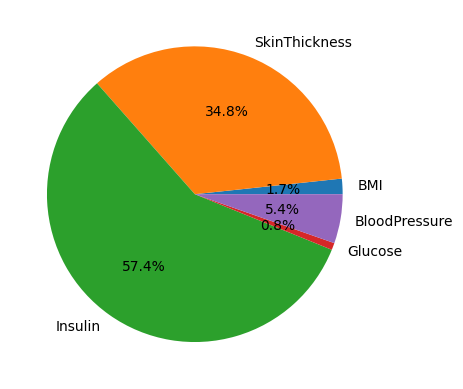

In [94]:
col_not_zero = ['BMI', 'SkinThickness', 'Insulin', 'Glucose', 'BloodPressure']
pct = []
for col in col_not_zero:
    zero = df[df[col] == 0][col].count()
    percentage = (zero / df.shape[0]) * 100
    pct.append(percentage)
    print(col, zero, f"{percentage:.2f}%")

plt.pie(pct, labels=col_not_zero, autopct='%1.1f%%')
plt.show()

# Replacing all zeros with the median

In [95]:
df_clean = df.copy()

for col in col_not_zero:
    df_clean[col] = df_clean[col].replace(0, df[col][df[col] != 0].median())

In [96]:
df_clean

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,125,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,29,125,30.1,0.349,47,1


In [97]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


# Handling Outliers

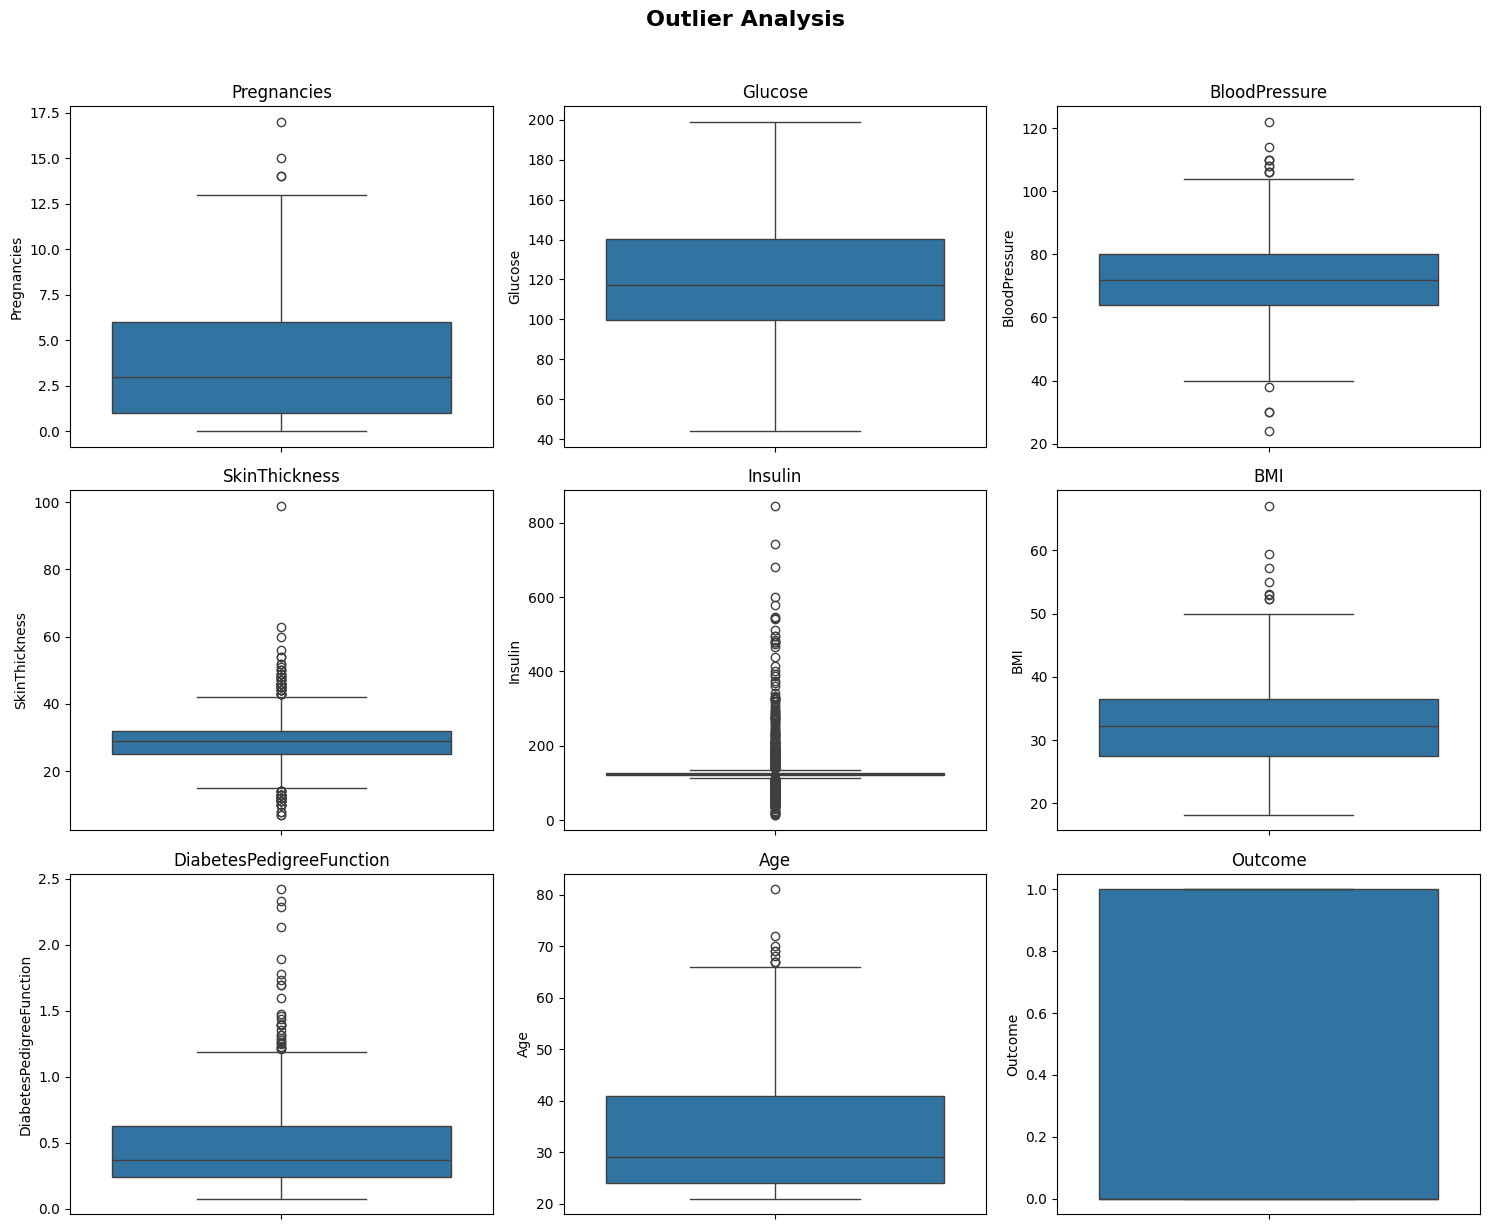

In [98]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(df_clean.columns):
    sns.boxplot(data=df_clean, y=col, ax=axes[i])
    axes[i].set_title(col)

fig.suptitle("Outlier Analysis", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [99]:
col_w_outlier = [feature for feature in df_clean.columns if feature != "Outcome" and feature !="Glucose"]

In [100]:
col_w_outlier

['Pregnancies',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

In [101]:
from scipy.stats import mstats

df_clean_no_outliers = df_clean.copy()
for col in col_w_outlier:
    df_clean_no_outliers[col] = mstats.winsorize(df_clean_no_outliers[col], limits=[0.05, 0.05])

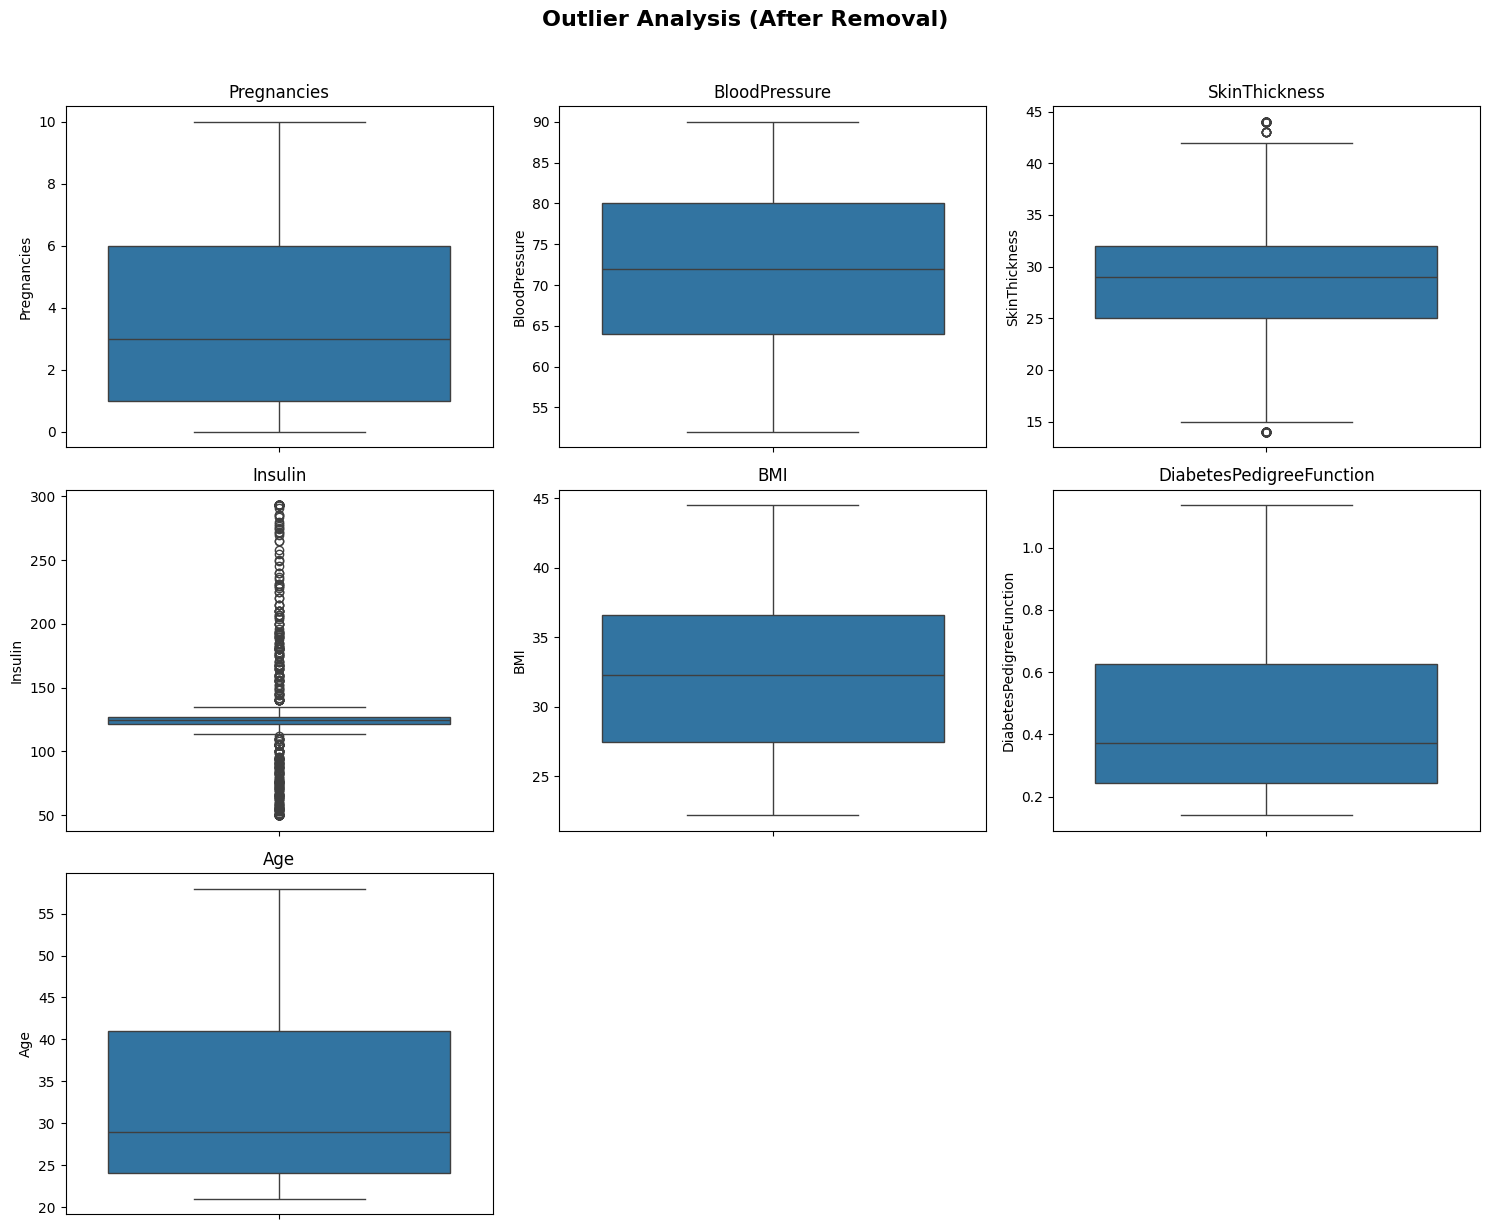

In [104]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(col_w_outlier):
    sns.boxplot(data=df_clean_no_outliers, y=col, ax=axes[i])
    axes[i].set_title(col)

axes[7].set_visible(False)
axes[8].set_visible(False)

fig.suptitle("Outlier Analysis (After Removal)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [103]:
df_clean_no_outliers

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,52,35,168,43.1,1.136,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,44,180,32.9,0.171,58,0
764,2,122,70,27,125,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,29,125,30.1,0.349,47,1


# EDA

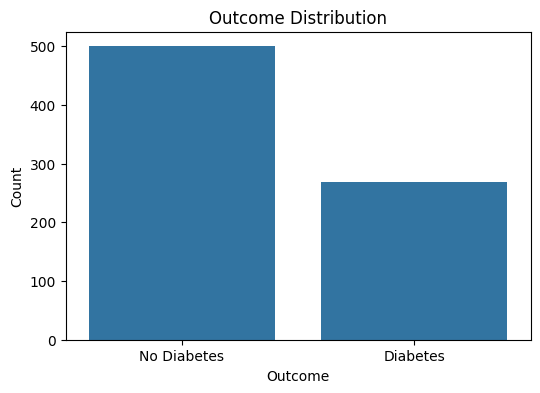

In [113]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean_no_outliers, x="Outcome")
plt.title("Outcome Distribution")
plt.xticks([0, 1], ["No Diabetes", "Diabetes"])
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

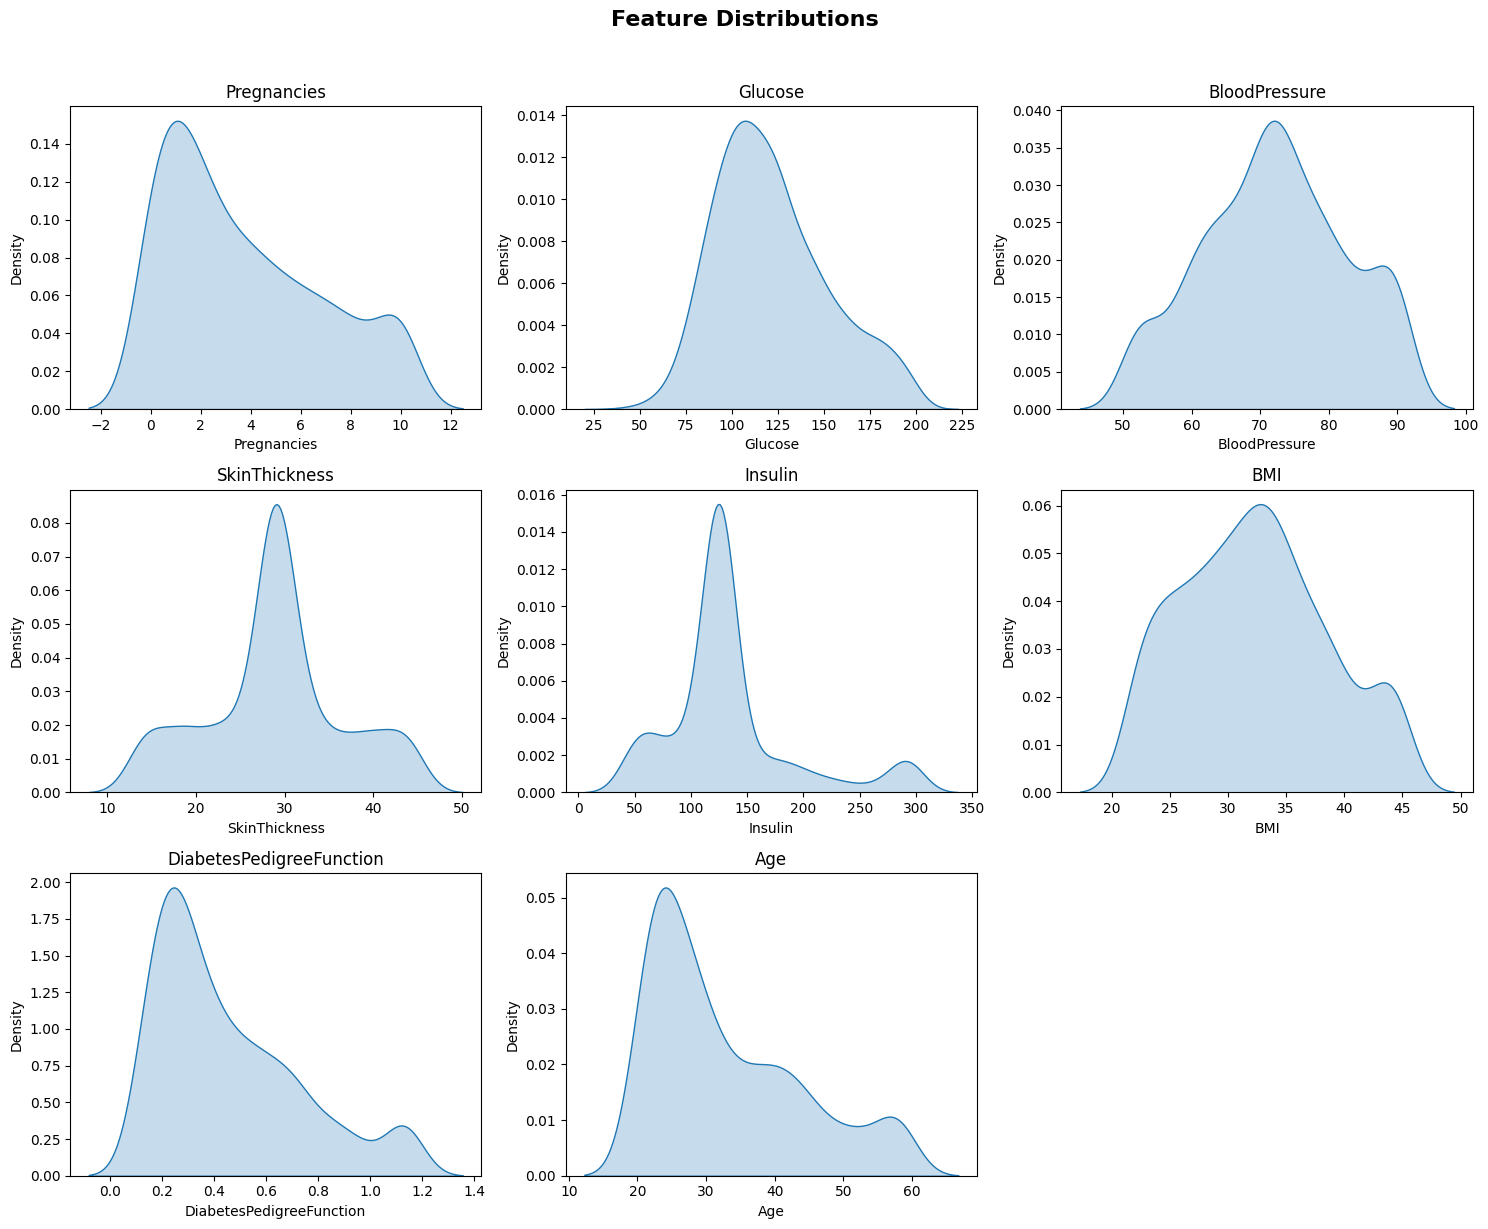

In [117]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(df_clean_no_outliers.columns):
    sns.kdeplot(data=df_clean_no_outliers, x=col, ax=axes[i], fill=True)
    axes[i].set_title(col)

axes[8].set_visible(False)

fig.suptitle("Feature Distributions", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<Axes: >

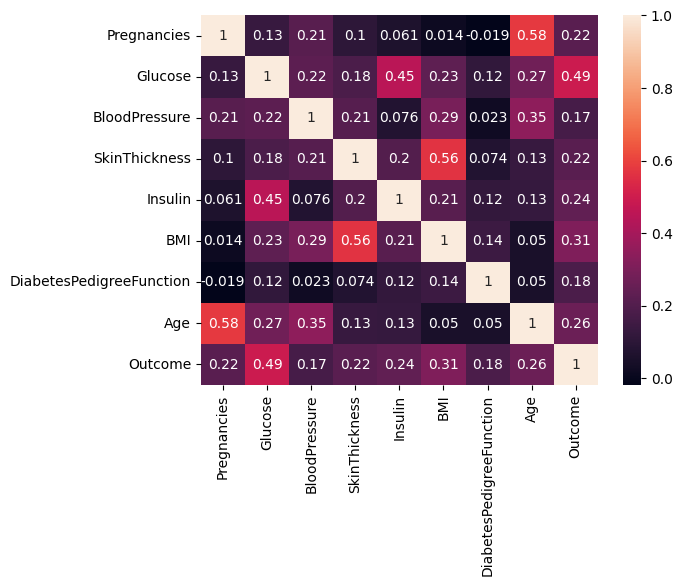

In [119]:
sns.heatmap(df_clean_no_outliers.corr(), annot=True)

In [120]:
df_clean_no_outliers

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,52,35,168,43.1,1.136,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,44,180,32.9,0.171,58,0
764,2,122,70,27,125,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,29,125,30.1,0.349,47,1


In [121]:
df_clean_no_outliers.to_csv("diabetes_clean.csv", index=False)